In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from encoder_decoder import*
import matplotlib.pyplot as plt

# Check vocab and define encoding/decoding functions (from int to char and viceversa)

In [2]:
# first import the little dictionary frol it_es_cognates.txt

italian_words = []
spanish_words = []

with open("it_es_cognates.txt", encoding="utf-8") as f:
    for line in f:
        line = line.strip()
        if not line or line.startswith("#"):
            continue
        it, es = line.split(";") # words separated by ;
        italian_words.append(it.lower())
        spanish_words.append(es.lower())

# check the number of words in the list of cognates
print(len(italian_words), "pairs")
print(italian_words[:5], spanish_words[:5])

# find all characters appearing in the list of cognates
all_chars = set()
for word in spanish_words + italian_words:
    all_chars.update(word)
all_chars = sorted(all_chars)

# add the special caracters: pad, start of string, end of string, unknown
specials = ['<pad>', '<sos>', '<eos>', '<unk>']
vocab = specials + all_chars

# build the dictionaries, just use the enumeration of vocab to assign an integer to every character
char_to_idx = {ch: i for i, ch in enumerate(vocab)}
idx_to_char = {i: ch for ch, i in char_to_idx.items()}

# check the characters in the vocabulary, and its length
print("vocab: ", vocab)
print("vocab length:", len(vocab))

# test word size in the vocabulary (need to know the dimension of the words I am going to have in the model - by padding)
# I will add 2 or 3 just to be on the safe side for future additions to the dictionary, getting, say, to 20
print("Max length of spanish words: ", max(len(w) for w in spanish_words))
print("Max length of italian words: ", max(len(w) for w in italian_words))

def encode_source(word, max_len = 20):
    # input: no sos/eos needed
    ids = [char_to_idx.get(c, char_to_idx['<unk>']) for c in word][:max_len] # use the char to int dictionary
    ids += [char_to_idx['<pad>']] * (max_len - len(ids)) # fill with '<pad>' until the prescribed length max_len
    return torch.tensor(ids)

def encode_target(word, max_len = 20):
    # output: needs sos/eos since decoder generates it step by step, they will replace two <pad> 
    ids = [char_to_idx['<sos>']] + [char_to_idx.get(c, char_to_idx['<unk>']) for c in word][:max_len-2] + [char_to_idx['<eos>']]
    ids += [char_to_idx['<pad>']] * (max_len - len(ids))
    return torch.tensor(ids) 

def decode_source(ids):
    
    ids_numpy = ids.numpy()
    chars = []
    for i in ids_numpy:
        ch = idx_to_char[i] # use the integer to char dictionary
        if ch == '<pad>':
            break  # padding marks the end of real content
        chars.append(ch)
    return ''.join(chars)

# test
print(encode_source('castoro'))
print(decode_source(encode_source('castoro'))) 
print(decode_source(encode_source('è'))) # check unknown characters


# now test the embedding
vocab_size = len(char_to_idx)
d_model = 32 # needs to be large enough but does not have to be larger than number of characters - in fact for LLMs it is smaller than the number of tokens
embed = nn.Embedding(vocab_size, d_model, padding_idx=char_to_idx['<pad>'])

print(embed(encode_source('castoro')))

908 pairs
['acqua', 'aglio', 'aiutare', 'aiutata', 'aiutate'] ['agua', 'ajo', 'ayudar', 'ayudada', 'ayudadas']
vocab:  ['<pad>', '<sos>', '<eos>', '<unk>', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'x', 'y', 'z', 'à', 'á', 'é', 'í', 'ñ', 'ó', 'ù', 'ú']
vocab length: 36
Max length of spanish words:  15
Max length of italian words:  13
tensor([ 6,  4, 21, 22, 17, 20, 17,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
         0,  0])
castoro
<unk>
tensor([[-5.2352e-01, -5.5820e-01,  6.6824e-01, -1.6614e+00, -1.0467e+00,
          3.1461e-01,  1.0878e+00, -9.2816e-02, -3.2164e-01, -7.7858e-01,
         -6.5408e-01, -2.3993e-01,  2.1100e+00, -7.2830e-01,  1.0665e+00,
          1.3039e+00,  1.0298e-01, -7.9252e-01,  1.2452e+00, -2.1698e+00,
         -6.2783e-01,  1.2818e+00, -2.8526e-01, -1.0710e+00, -1.0227e+00,
         -2.0208e+00, -9.5671e-01,  1.0501e+00, -1.7371e+00,  3.4204e-01,
         -3.6403e-01, -1.1720e+00],
        [-

# Various tests done while coding the class

In [3]:
# test if Encoder runs correctly

enco = Encoder(2, d_model = d_model, d_hidden = 4*d_model, dk = 8, dv = 8, h = 4)
pos_enco = PositionalEncodingModule(d_model=d_model)

encoded_word = pos_enco(enco(embed(encode_source('castoro')).unsqueeze(0)))
# print(encoded_word)

# ok

# test if Transformer runs correctly 

trafo = Transformer(n_layers = 3, d_model = d_model, vocab_size = vocab_size, char_to_idx = char_to_idx, dk = 8, dv = 8)

print(trafo(encode_source("castoro").unsqueeze(0), encode_source("diga").unsqueeze(0)))
print(trafo.generate_sequence(encode_source("castoro").unsqueeze(0)))

tensor([[[ 1.0216e+00,  4.5488e-01, -4.7597e-01,  5.9119e-01, -1.1358e+00,
          -8.8753e-01, -1.9828e-01,  4.6658e-02, -3.5869e-01, -1.7383e-01,
           6.4562e-01,  9.7269e-01, -5.9495e-01,  1.5718e-01, -4.2391e-01,
          -4.1836e-02,  4.5911e-01, -1.1616e+00,  7.4079e-01,  6.1041e-02,
           5.5677e-02,  4.6888e-01,  4.1335e-01, -4.8585e-01,  9.7996e-02,
          -1.8029e-01,  8.2864e-02, -3.0108e-01,  2.3218e-01, -4.2572e-02,
          -4.3498e-03, -2.4111e-01, -2.0370e-01,  3.3772e-01, -5.6554e-01,
           5.1426e-02],
         [ 8.6594e-01, -6.7124e-02,  9.7102e-02,  8.6973e-01,  2.2727e-01,
           2.7273e-01, -8.9181e-01,  6.7411e-01,  1.4966e-01,  1.8477e-01,
           5.8244e-01, -2.8221e-02, -4.8940e-01,  2.3924e-01, -7.1526e-01,
           2.9809e-01, -7.2111e-01, -1.0847e+00,  2.9312e-01, -7.4135e-02,
           1.2748e-01,  9.1945e-01, -3.5062e-01, -7.8235e-01, -2.3133e-01,
           3.9724e-01,  4.3778e-01,  3.4707e-01,  3.2533e-01, -3.3487e-02,
 

In [4]:
def count_parameters_by_module(model: nn.Module, trainable_only: bool = True) -> dict:
    """counts the number of parameters, in total and for every submodule"""
    counts = {}
    for name, module in model.named_children():
        if trainable_only:
            n = sum(p.numel() for p in module.parameters() if p.requires_grad)
        else:
            n = sum(p.numel() for p in module.parameters())
        counts[name] = n
    counts["TOTAL"] = sum(counts.values())
    return counts

count_parameters_by_module(trafo)

{'embed': 1152,
 'pos_encoding': 0,
 'encoder': 38112,
 'decoder': 50976,
 'exit_linear_projection': 1188,
 'criterion': 0,
 'TOTAL': 91428}

# Fit the model

In [ ]:
trafo = Transformer(n_layers = 3, d_model = d_model, vocab_size = vocab_size, char_to_idx = char_to_idx, dk = 8, dv = 8, lr = 0.01)
# lr = 0.01 seems to work as starting learning rate
trafo.fit_from_txt("it_es_cognates.txt", n_epochs=750)

Epoch  0 / 750  loss =  3.8594748973846436
Epoch  100 / 750  loss =  0.11587096005678177
Epoch  200 / 750  loss =  0.005566258914768696
Epoch  300 / 750  loss =  0.0033633706625550985
Epoch  400 / 750  loss =  0.002766310004517436


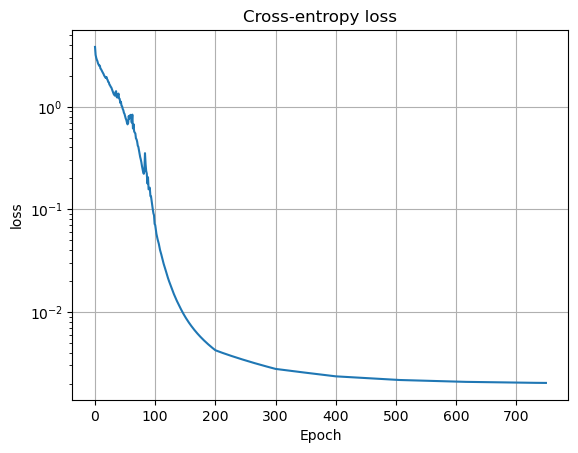

In [27]:
plt.figure()
plt.title('Cross-entropy loss')
plt.xlabel('Epoch')
plt.ylabel('loss')
plt.grid()
plt.semilogy(trafo.epochs, trafo.losses)
plt.show()

def translate_string(word):
    encoded_input = encode_source(word).unsqueeze(0)
    generated_sequence = trafo.generate_sequence(encoded_input).cpu().squeeze()[1:-1] # exclude sos at beginning and eos at end

    return decode_source(generated_sequence)

In [24]:
italian_words = ["aiutato", "aiutate", "speciale", "speciali", "sperato", "letto", "letti", "gatto", "andato"]
expected_spanish_cognates = [translate_string(word) for word in italian_words]

for k in range(len(italian_words)):
    print(italian_words[k], "  ", expected_spanish_cognates[k])

aiutato    ayudado
aiutate    ayudadas
speciale    especial
speciali    especiol
sperato    esperado
letto    lecho
letti    ilechtios
gatto    gato
andato    adonta


In [ ]:
# basically, overfit: works fine on training dataset but not very well on random words
# need bigger dataset